# Ejercicio 4 — Imagen = Matriz (Canales, Slicing, Histogramas)

## Meta
Manipular pixeles y regiones directamente usando OpenCV y NumPy.

## Tareas
1. Separar canales RGB/HSV
2. Editar regiones por slicing (cambiar color, copiar/pegar regiones)
3. Histograma de intensidades
4. Brillo/contraste (manual u OpenCV)
5. **Bonus**: Sliders interactivos

## Evidencia
Antes/después por regiones + histogramas

## 1. Importar librerías y cargar imagen

Dimensiones de la imagen: (1308, 736, 3)
Tipo de datos: uint8
Rango de valores: [0, 255]


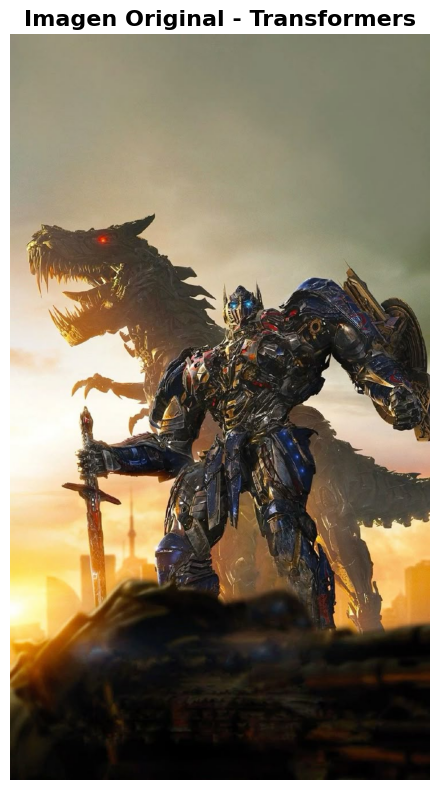

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import warnings
warnings.filterwarnings('ignore')

# Configurar matplotlib para mostrar gráficos en línea
%matplotlib inline

# Cargar la imagen
img = cv2.imread('taller2.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print(f"Dimensiones de la imagen: {img_rgb.shape}")
print(f"Tipo de datos: {img_rgb.dtype}")
print(f"Rango de valores: [{img_rgb.min()}, {img_rgb.max()}]")

# Mostrar imagen original
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.title('Imagen Original - Transformers', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Separación de Canales RGB

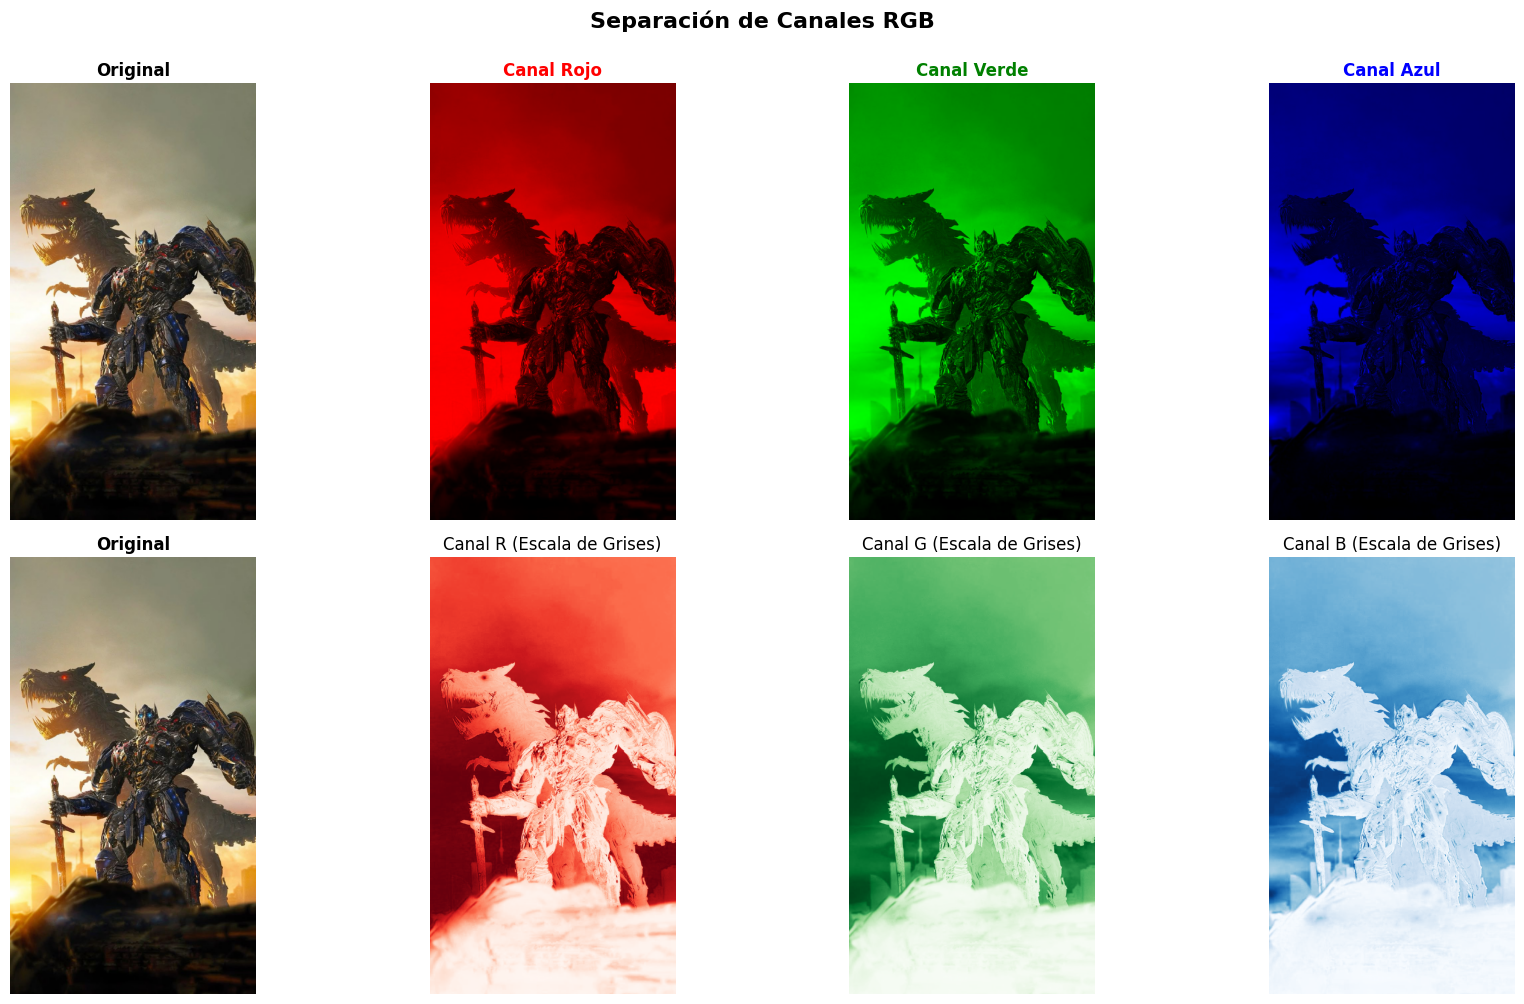

Estadísticas por canal:
Canal R - Media: 118.16, Std: 79.61, Min: 0, Max: 255
Canal G - Media: 105.63, Std: 73.73, Min: 0, Max: 255
Canal B - Media: 83.21, Std: 63.34, Min: 0, Max: 255


In [2]:
# Separar canales RGB
R, G, B = cv2.split(img_rgb)

# Crear imágenes para cada canal (solo mostrando un canal a la vez)
img_r = np.zeros_like(img_rgb)
img_r[:, :, 0] = R

img_g = np.zeros_like(img_rgb)
img_g[:, :, 1] = G

img_b = np.zeros_like(img_rgb)
img_b[:, :, 2] = B

# Visualizar canales
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# Fila 1: Imagen original y canales en color
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_r)
axes[0, 1].set_title('Canal Rojo', fontsize=12, fontweight='bold', color='red')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_g)
axes[0, 2].set_title('Canal Verde', fontsize=12, fontweight='bold', color='green')
axes[0, 2].axis('off')

axes[0, 3].imshow(img_b)
axes[0, 3].set_title('Canal Azul', fontsize=12, fontweight='bold', color='blue')
axes[0, 3].axis('off')

# Fila 2: Canales en escala de grises
axes[1, 0].imshow(img_rgb)
axes[1, 0].set_title('Original', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(R, cmap='Reds')
axes[1, 1].set_title('Canal R (Escala de Grises)', fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(G, cmap='Greens')
axes[1, 2].set_title('Canal G (Escala de Grises)', fontsize=12)
axes[1, 2].axis('off')

axes[1, 3].imshow(B, cmap='Blues')
axes[1, 3].set_title('Canal B (Escala de Grises)', fontsize=12)
axes[1, 3].axis('off')

plt.suptitle('Separación de Canales RGB', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

print(f"Estadísticas por canal:")
print(f"Canal R - Media: {R.mean():.2f}, Std: {R.std():.2f}, Min: {R.min()}, Max: {R.max()}")
print(f"Canal G - Media: {G.mean():.2f}, Std: {G.std():.2f}, Min: {G.min()}, Max: {G.max()}")
print(f"Canal B - Media: {B.mean():.2f}, Std: {B.std():.2f}, Min: {B.min()}, Max: {B.max()}")

## 3. Conversión a HSV y Separación de Canales

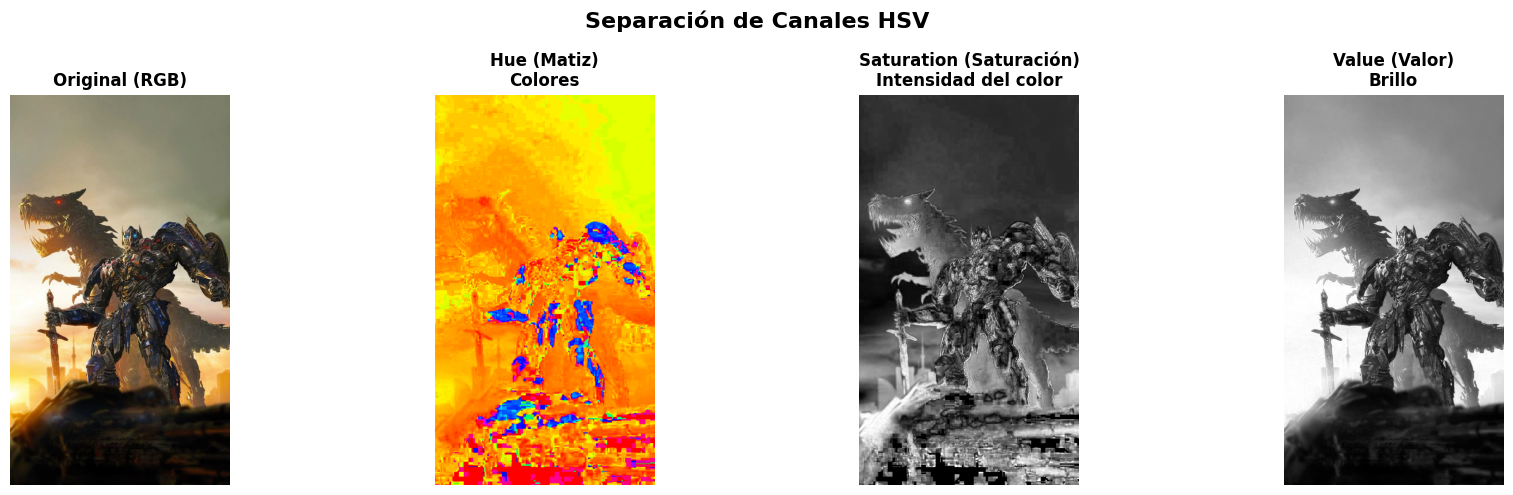

Estadísticas HSV:
Canal H (Hue) - Media: 29.35, Std: 32.66, Min: 0, Max: 179
Canal S (Saturation) - Media: 82.59, Std: 56.56, Min: 0, Max: 255
Canal V (Value) - Media: 118.95, Std: 79.19, Min: 0, Max: 255


In [3]:
# Convertir a HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
H, S, V = cv2.split(img_hsv)

# Visualizar canales HSV
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img_rgb)
axes[0].set_title('Original (RGB)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(H, cmap='hsv')
axes[1].set_title('Hue (Matiz)\nColores', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(S, cmap='gray')
axes[2].set_title('Saturation (Saturación)\nIntensidad del color', fontsize=12, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(V, cmap='gray')
axes[3].set_title('Value (Valor)\nBrillo', fontsize=12, fontweight='bold')
axes[3].axis('off')

plt.suptitle('Separación de Canales HSV', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Estadísticas HSV:")
print(f"Canal H (Hue) - Media: {H.mean():.2f}, Std: {H.std():.2f}, Min: {H.min()}, Max: {H.max()}")
print(f"Canal S (Saturation) - Media: {S.mean():.2f}, Std: {S.std():.2f}, Min: {S.min()}, Max: {S.max()}")
print(f"Canal V (Value) - Media: {V.mean():.2f}, Std: {V.std():.2f}, Min: {V.min()}, Max: {V.max()}")

## 4. Edición de Regiones por Slicing - Cambiar Color

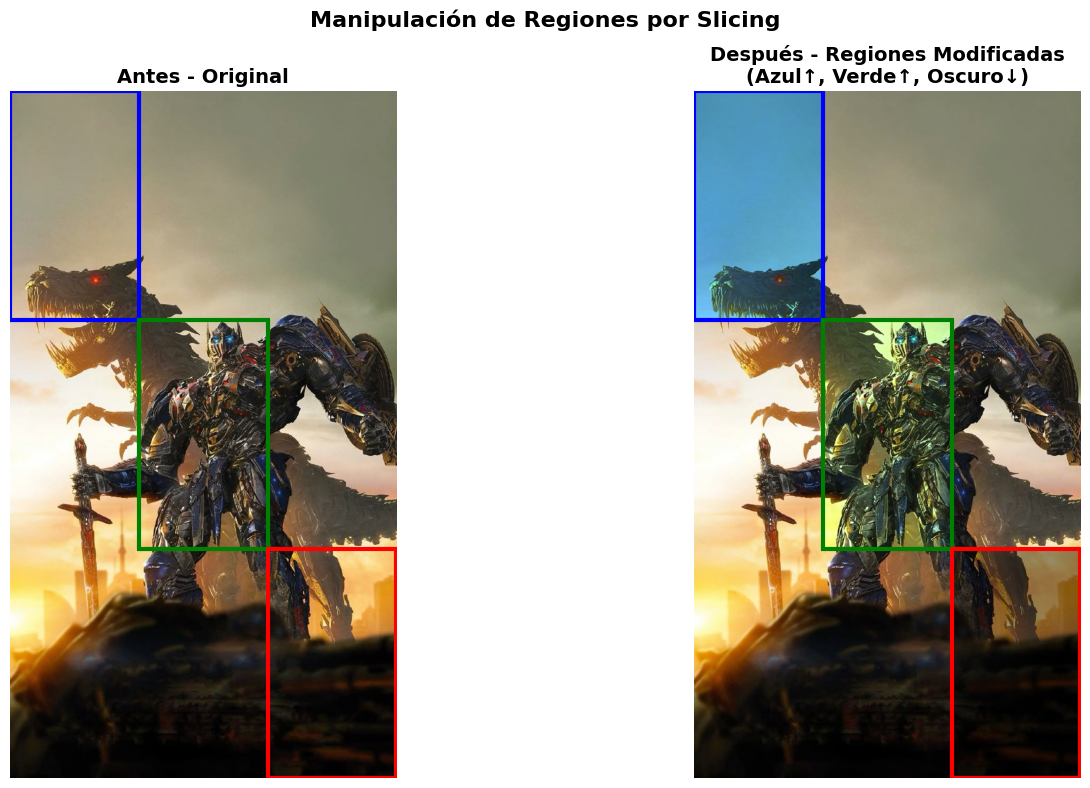

In [4]:
# Crear copia de la imagen para manipular
img_modified = img_rgb.copy()

# Obtener dimensiones
height, width = img_rgb.shape[:2]

# 1. Cambiar color de una región (parte superior izquierda) a tono azul
img_modified[0:height//3, 0:width//3, 0] = img_modified[0:height//3, 0:width//3, 0] * 0.5  # Reducir rojo
img_modified[0:height//3, 0:width//3, 2] = np.clip(img_modified[0:height//3, 0:width//3, 2] * 1.5, 0, 255)  # Aumentar azul

# 2. Cambiar región central a tono verdoso
center_y_start = height//3
center_y_end = 2*height//3
center_x_start = width//3
center_x_end = 2*width//3
img_modified[center_y_start:center_y_end, center_x_start:center_x_end, 1] = np.clip(
    img_modified[center_y_start:center_y_end, center_x_start:center_x_end, 1] * 1.3, 0, 255
)

# 3. Oscurecer región inferior derecha
img_modified[2*height//3:, 2*width//3:] = img_modified[2*height//3:, 2*width//3:] * 0.6

# Visualizar antes y después
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img_rgb)
axes[0].set_title('Antes - Original', fontsize=14, fontweight='bold')
axes[0].add_patch(plt.Rectangle((0, 0), width//3, height//3, fill=False, edgecolor='blue', linewidth=3))
axes[0].add_patch(plt.Rectangle((width//3, height//3), width//3, height//3, fill=False, edgecolor='green', linewidth=3))
axes[0].add_patch(plt.Rectangle((2*width//3, 2*height//3), width//3, height//3, fill=False, edgecolor='red', linewidth=3))
axes[0].axis('off')

axes[1].imshow(img_modified)
axes[1].set_title('Después - Regiones Modificadas\n(Azul↑, Verde↑, Oscuro↓)', fontsize=14, fontweight='bold')
axes[1].add_patch(plt.Rectangle((0, 0), width//3, height//3, fill=False, edgecolor='blue', linewidth=3))
axes[1].add_patch(plt.Rectangle((width//3, height//3), width//3, height//3, fill=False, edgecolor='green', linewidth=3))
axes[1].add_patch(plt.Rectangle((2*width//3, 2*height//3), width//3, height//3, fill=False, edgecolor='red', linewidth=3))
axes[1].axis('off')

plt.suptitle('Manipulación de Regiones por Slicing', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Copiar y Pegar Regiones

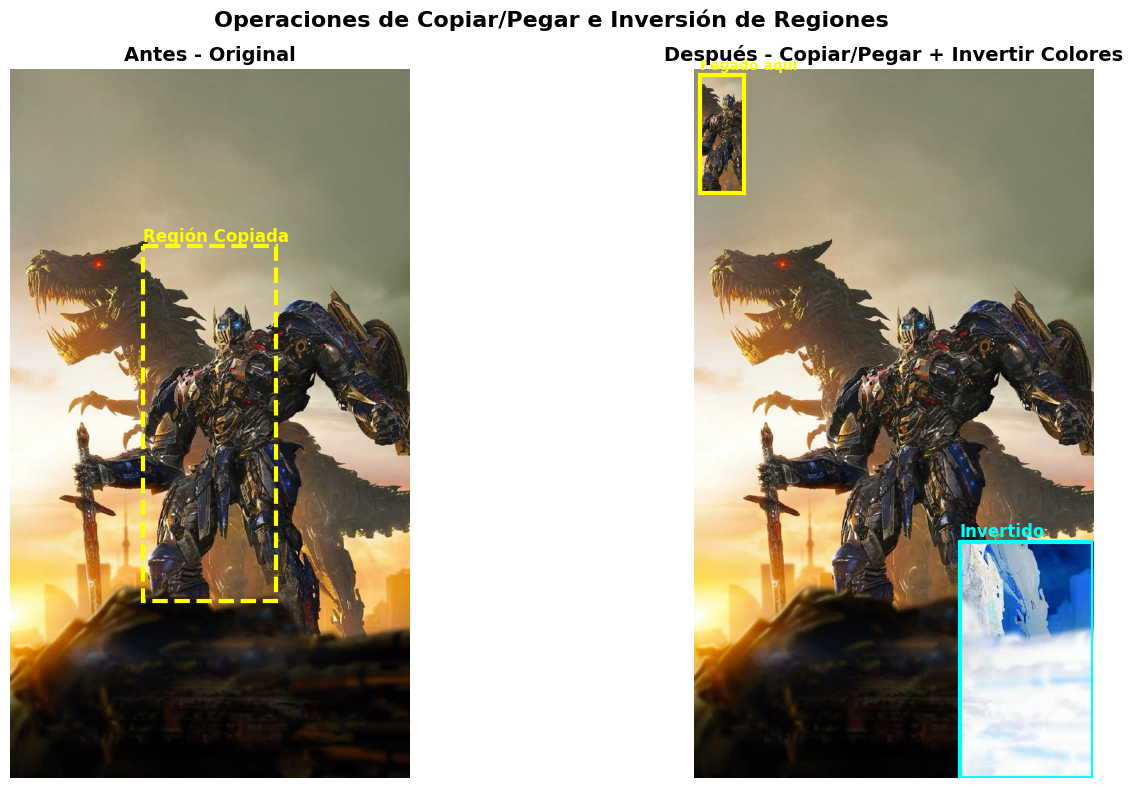

In [5]:
# Crear copia para operación de copiar/pegar
img_copy_paste = img_rgb.copy()

# Copiar la región del robot (centro) y pegarla en diferentes posiciones
# Definir región a copiar (aproximadamente el robot Optimus Prime)
y_start, y_end = height//4, 3*height//4
x_start, x_end = width//3, 2*width//3
region_robot = img_rgb[y_start:y_end, x_start:x_end].copy()

# Pegar la región en la esquina superior izquierda (más pequeña)
small_h = (y_end - y_start) // 3
small_w = (x_end - x_start) // 3
region_small = cv2.resize(region_robot, (small_w, small_h))
img_copy_paste[10:10+small_h, 10:10+small_w] = region_small

# Invertir colores de una región (inferior derecha)
y_inv_start = 2*height//3
x_inv_start = 2*width//3
img_copy_paste[y_inv_start:, x_inv_start:] = 255 - img_copy_paste[y_inv_start:, x_inv_start:]

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img_rgb)
axes[0].set_title('Antes - Original', fontsize=14, fontweight='bold')
axes[0].add_patch(plt.Rectangle((x_start, y_start), x_end-x_start, y_end-y_start, 
                                 fill=False, edgecolor='yellow', linewidth=3, linestyle='--'))
axes[0].text(x_start, y_start-10, 'Región Copiada', color='yellow', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_copy_paste)
axes[1].set_title('Después - Copiar/Pegar + Invertir Colores', fontsize=14, fontweight='bold')
axes[1].add_patch(plt.Rectangle((10, 10), small_w, small_h, 
                                 fill=False, edgecolor='yellow', linewidth=3))
axes[1].text(10, 0, 'Pegado aquí', color='yellow', fontsize=10, fontweight='bold')
axes[1].add_patch(plt.Rectangle((x_inv_start, y_inv_start), width-x_inv_start, height-y_inv_start, 
                                 fill=False, edgecolor='cyan', linewidth=3))
axes[1].text(x_inv_start, y_inv_start-10, 'Invertido', color='cyan', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.suptitle('Operaciones de Copiar/Pegar e Inversión de Regiones', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Histogramas de Intensidades - RGB

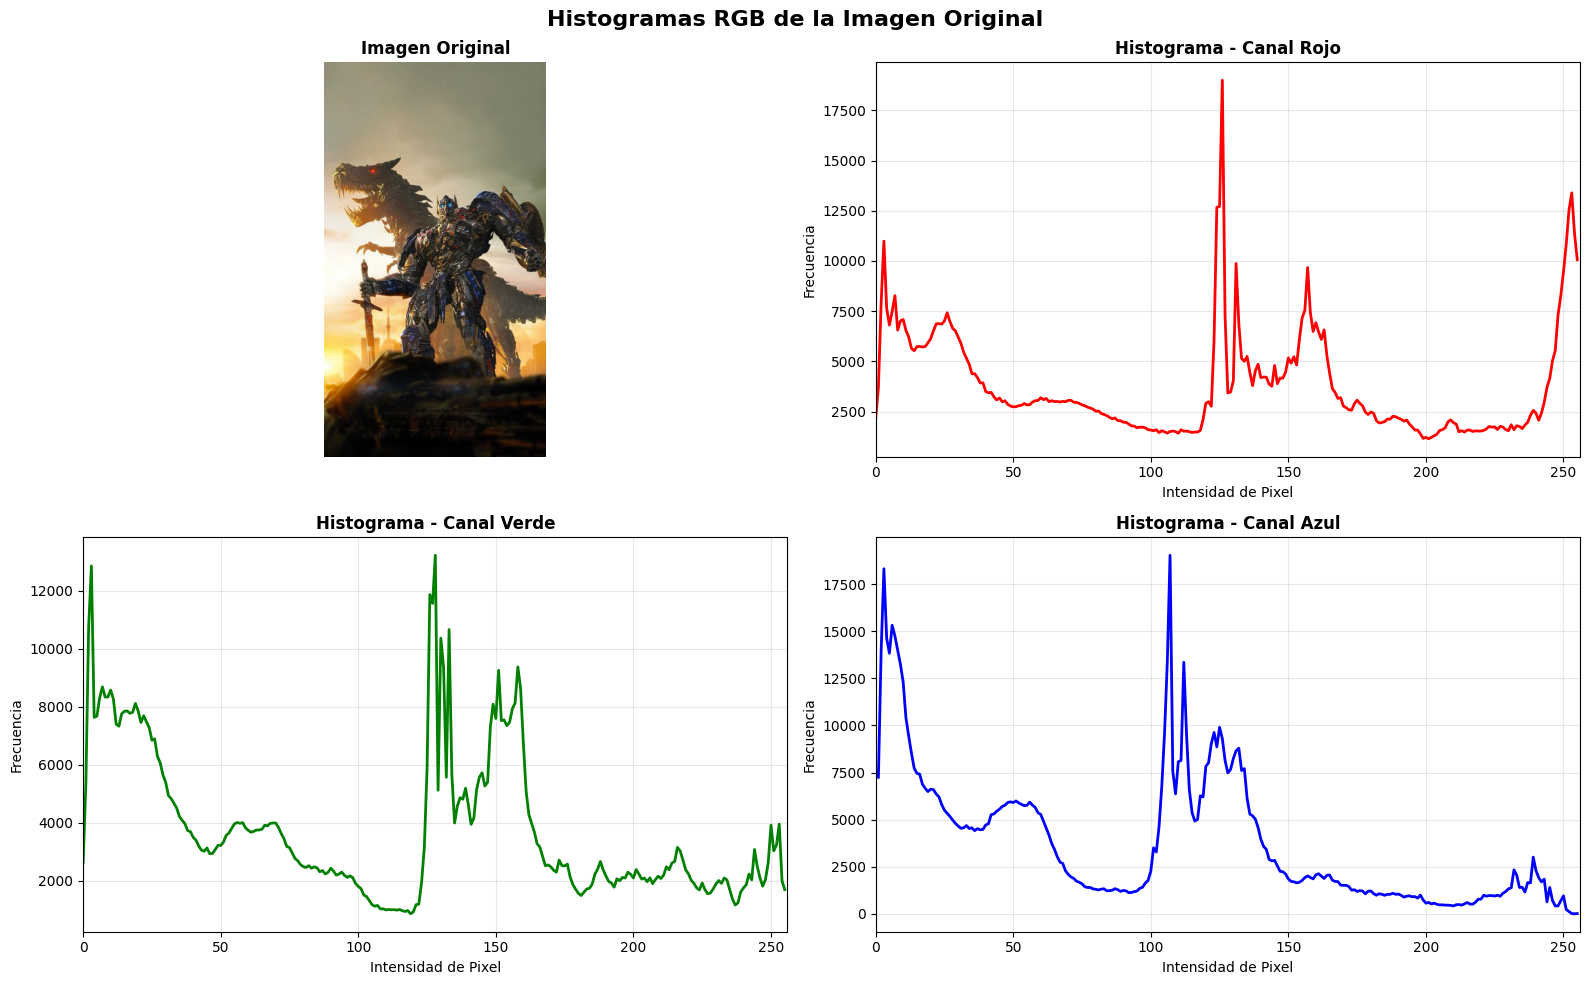

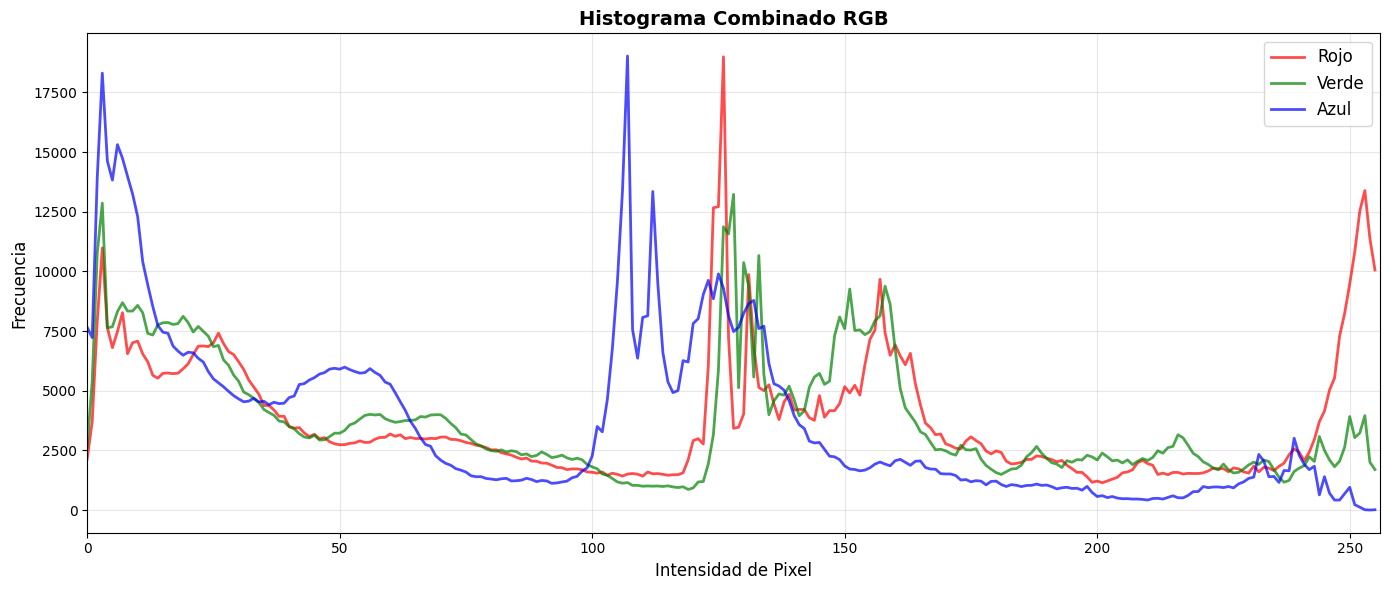

In [6]:
# Calcular histogramas para cada canal RGB
hist_r = cv2.calcHist([img_rgb], [0], None, [256], [0, 256])
hist_g = cv2.calcHist([img_rgb], [1], None, [256], [0, 256])
hist_b = cv2.calcHist([img_rgb], [2], None, [256], [0, 256])

# Visualizar histogramas
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Imagen original
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Imagen Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Histograma canal Rojo
axes[0, 1].plot(hist_r, color='red', linewidth=2)
axes[0, 1].set_title('Histograma - Canal Rojo', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Intensidad de Pixel')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim([0, 256])

# Histograma canal Verde
axes[1, 0].plot(hist_g, color='green', linewidth=2)
axes[1, 0].set_title('Histograma - Canal Verde', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Intensidad de Pixel')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim([0, 256])

# Histograma canal Azul
axes[1, 1].plot(hist_b, color='blue', linewidth=2)
axes[1, 1].set_title('Histograma - Canal Azul', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Intensidad de Pixel')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim([0, 256])

plt.suptitle('Histogramas RGB de la Imagen Original', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Histograma combinado
plt.figure(figsize=(14, 6))
plt.plot(hist_r, color='red', linewidth=2, alpha=0.7, label='Rojo')
plt.plot(hist_g, color='green', linewidth=2, alpha=0.7, label='Verde')
plt.plot(hist_b, color='blue', linewidth=2, alpha=0.7, label='Azul')
plt.title('Histograma Combinado RGB', fontsize=14, fontweight='bold')
plt.xlabel('Intensidad de Pixel', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim([0, 256])
plt.tight_layout()
plt.show()

## 7. Ajuste Manual de Brillo y Contraste

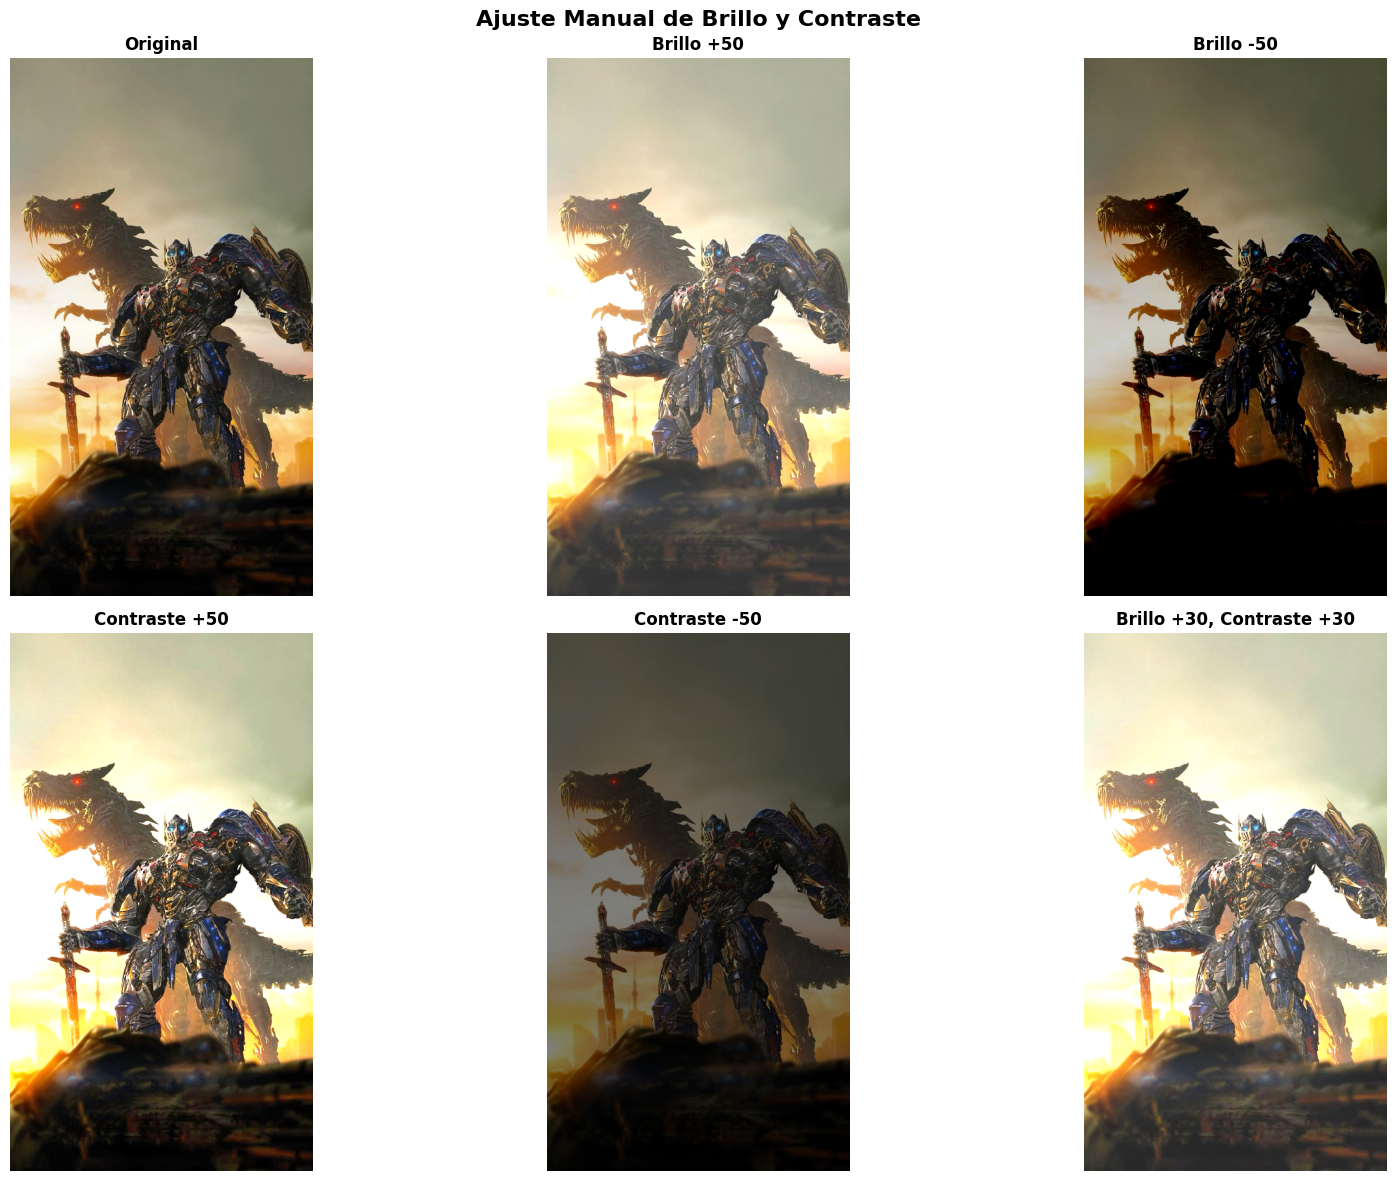

In [7]:
def adjust_brightness_contrast(image, brightness=0, contrast=0):
    """
    Ajusta brillo y contraste de la imagen.
    brightness: valores entre -100 y 100
    contrast: valores entre -100 y 100
    """
    # Convertir a float para evitar overflow
    img_float = image.astype(np.float32)
    
    # Ajustar brillo (añadir un valor constante)
    img_float = img_float + brightness
    
    # Ajustar contraste (multiplicar por un factor)
    # Contraste: (1 + contrast/100) para tener un rango más intuitivo
    contrast_factor = 1 + (contrast / 100)
    img_float = img_float * contrast_factor
    
    # Recortar valores entre 0 y 255
    img_adjusted = np.clip(img_float, 0, 255).astype(np.uint8)
    
    return img_adjusted

# Crear diferentes versiones con ajustes
img_bright_up = adjust_brightness_contrast(img_rgb, brightness=50, contrast=0)
img_bright_down = adjust_brightness_contrast(img_rgb, brightness=-50, contrast=0)
img_contrast_up = adjust_brightness_contrast(img_rgb, brightness=0, contrast=50)
img_contrast_down = adjust_brightness_contrast(img_rgb, brightness=0, contrast=-50)
img_both = adjust_brightness_contrast(img_rgb, brightness=30, contrast=30)

# Visualizar
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_bright_up)
axes[0, 1].set_title('Brillo +50', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_bright_down)
axes[0, 2].set_title('Brillo -50', fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(img_contrast_up)
axes[1, 0].set_title('Contraste +50', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_contrast_down)
axes[1, 1].set_title('Contraste -50', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(img_both)
axes[1, 2].set_title('Brillo +30, Contraste +30', fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('Ajuste Manual de Brillo y Contraste', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Comparación de Histogramas - Antes y Después del Ajuste

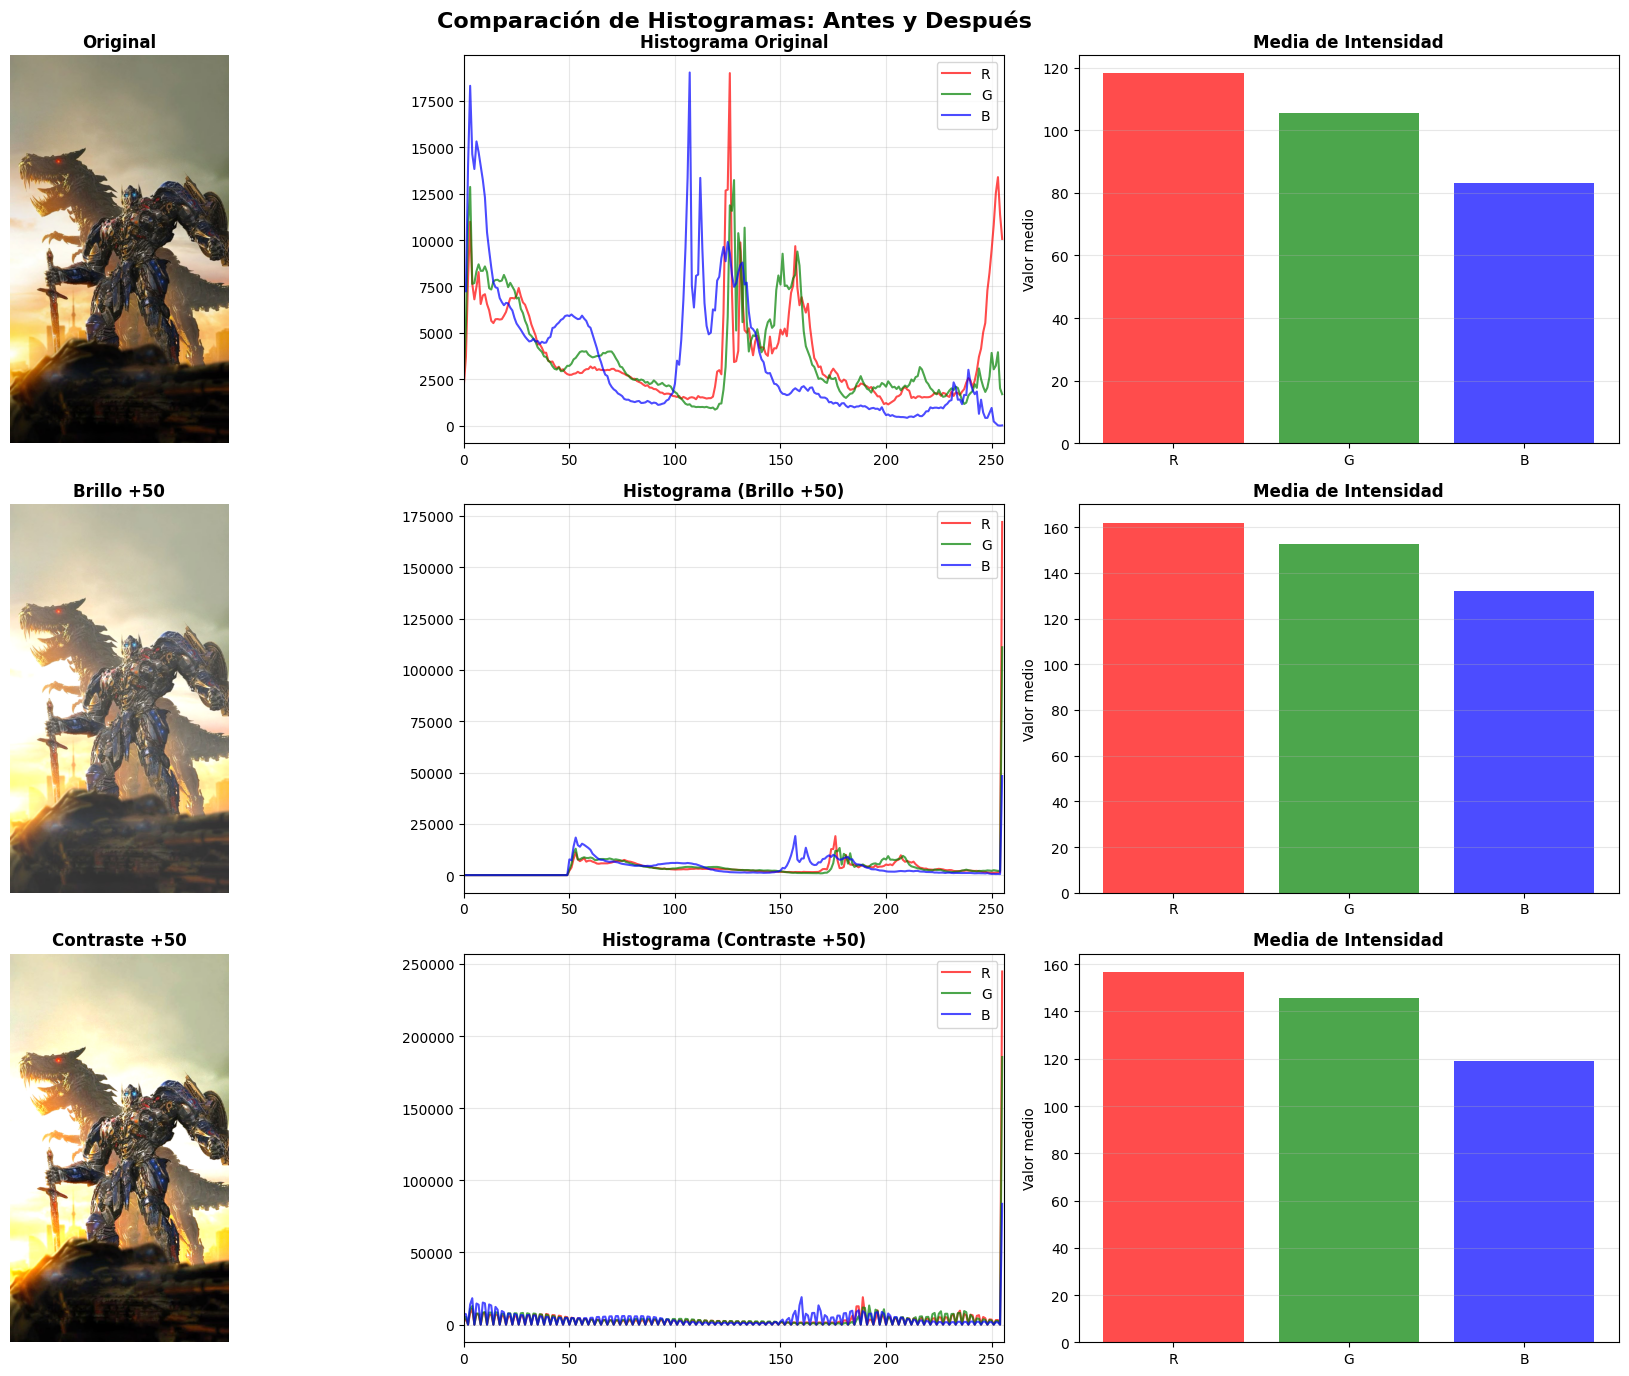

Análisis de cambios:

Original - Media RGB: R=118.16, G=105.63, B=83.21
Brillo +50 - Media RGB: R=161.87, G=152.69, B=131.88
Contraste +50 - Media RGB: R=156.58, G=145.83, B=119.14


In [8]:
# Calcular histogramas de la imagen con más brillo
hist_r_bright = cv2.calcHist([img_bright_up], [0], None, [256], [0, 256])
hist_g_bright = cv2.calcHist([img_bright_up], [1], None, [256], [0, 256])
hist_b_bright = cv2.calcHist([img_bright_up], [2], None, [256], [0, 256])

# Calcular histogramas de la imagen con más contraste
hist_r_contrast = cv2.calcHist([img_contrast_up], [0], None, [256], [0, 256])
hist_g_contrast = cv2.calcHist([img_contrast_up], [1], None, [256], [0, 256])
hist_b_contrast = cv2.calcHist([img_contrast_up], [2], None, [256], [0, 256])

# Visualización comparativa
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# Fila 1: Original
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].plot(hist_r, color='red', alpha=0.7, label='R')
axes[0, 1].plot(hist_g, color='green', alpha=0.7, label='G')
axes[0, 1].plot(hist_b, color='blue', alpha=0.7, label='B')
axes[0, 1].set_title('Histograma Original', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim([0, 256])

axes[0, 2].bar(['R', 'G', 'B'], 
               [R.mean(), G.mean(), B.mean()], 
               color=['red', 'green', 'blue'], alpha=0.7)
axes[0, 2].set_title('Media de Intensidad', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('Valor medio')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# Fila 2: Brillo aumentado
axes[1, 0].imshow(img_bright_up)
axes[1, 0].set_title('Brillo +50', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].plot(hist_r_bright, color='red', alpha=0.7, label='R')
axes[1, 1].plot(hist_g_bright, color='green', alpha=0.7, label='G')
axes[1, 1].plot(hist_b_bright, color='blue', alpha=0.7, label='B')
axes[1, 1].set_title('Histograma (Brillo +50)', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim([0, 256])

R_br, G_br, B_br = cv2.split(img_bright_up)
axes[1, 2].bar(['R', 'G', 'B'], 
               [R_br.mean(), G_br.mean(), B_br.mean()], 
               color=['red', 'green', 'blue'], alpha=0.7)
axes[1, 2].set_title('Media de Intensidad', fontsize=12, fontweight='bold')
axes[1, 2].set_ylabel('Valor medio')
axes[1, 2].grid(True, alpha=0.3, axis='y')

# Fila 3: Contraste aumentado
axes[2, 0].imshow(img_contrast_up)
axes[2, 0].set_title('Contraste +50', fontsize=12, fontweight='bold')
axes[2, 0].axis('off')

axes[2, 1].plot(hist_r_contrast, color='red', alpha=0.7, label='R')
axes[2, 1].plot(hist_g_contrast, color='green', alpha=0.7, label='G')
axes[2, 1].plot(hist_b_contrast, color='blue', alpha=0.7, label='B')
axes[2, 1].set_title('Histograma (Contraste +50)', fontsize=12, fontweight='bold')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].set_xlim([0, 256])

R_ct, G_ct, B_ct = cv2.split(img_contrast_up)
axes[2, 2].bar(['R', 'G', 'B'], 
               [R_ct.mean(), G_ct.mean(), B_ct.mean()], 
               color=['red', 'green', 'blue'], alpha=0.7)
axes[2, 2].set_title('Media de Intensidad', fontsize=12, fontweight='bold')
axes[2, 2].set_ylabel('Valor medio')
axes[2, 2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparación de Histogramas: Antes y Después', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Análisis de cambios:")
print(f"\nOriginal - Media RGB: R={R.mean():.2f}, G={G.mean():.2f}, B={B.mean():.2f}")
print(f"Brillo +50 - Media RGB: R={R_br.mean():.2f}, G={G_br.mean():.2f}, B={B_br.mean():.2f}")
print(f"Contraste +50 - Media RGB: R={R_ct.mean():.2f}, G={G_ct.mean():.2f}, B={B_ct.mean():.2f}")

## 9. Ajuste con OpenCV - convertScaleAbs()

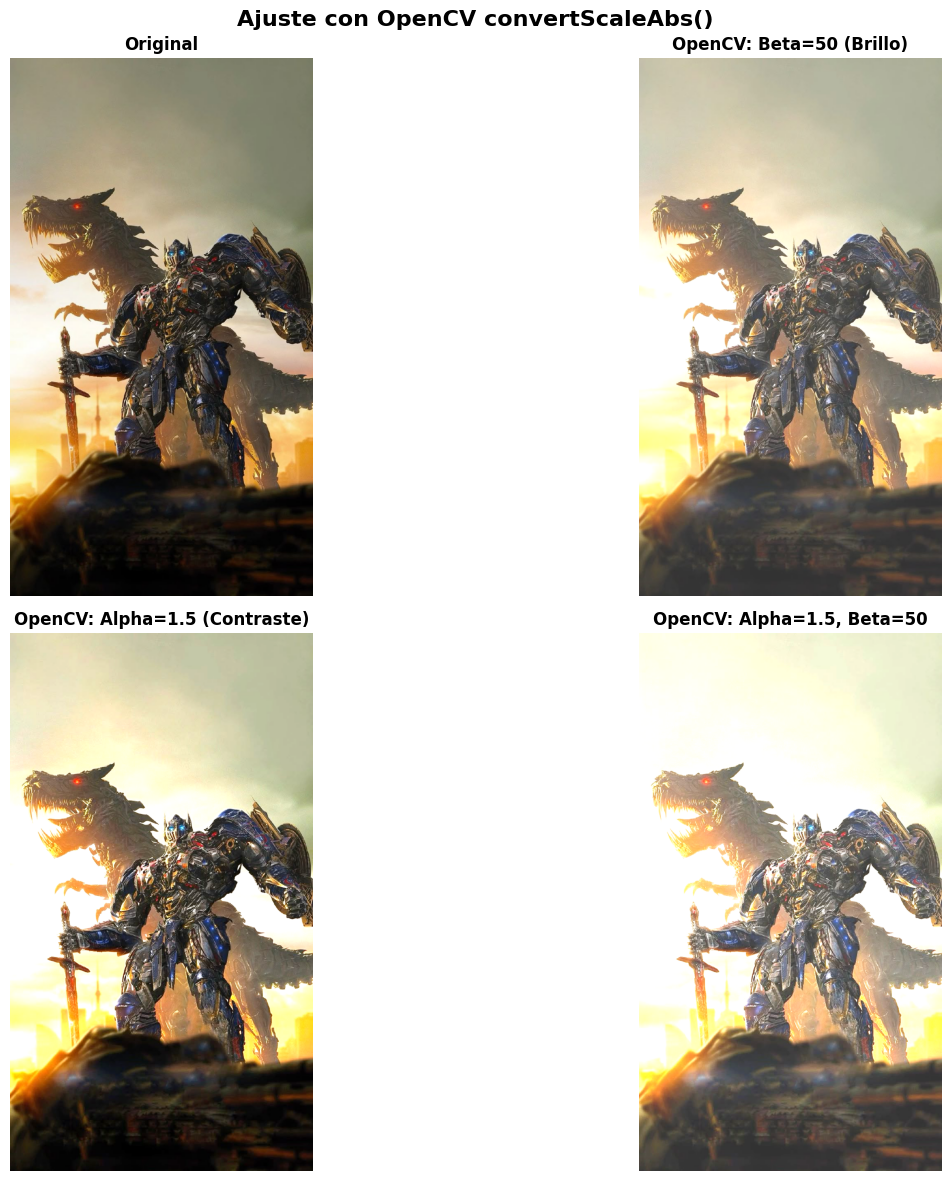

Parámetros OpenCV:
Alpha (contraste): 1.5
Beta (brillo): 50

Fórmula: new_img = alpha * img + beta


In [9]:
# Usando la función de OpenCV para ajustar brillo y contraste
# Fórmula: new_img = alpha * img + beta
# alpha > 1: aumenta contraste, alpha < 1: reduce contraste
# beta > 0: aumenta brillo, beta < 0: reduce brillo

alpha_high = 1.5  # Contraste
beta_high = 50    # Brillo
img_opencv_bright = cv2.convertScaleAbs(img_rgb, alpha=1.0, beta=beta_high)
img_opencv_contrast = cv2.convertScaleAbs(img_rgb, alpha=alpha_high, beta=0)
img_opencv_both = cv2.convertScaleAbs(img_rgb, alpha=alpha_high, beta=beta_high)

# Visualizar
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_opencv_bright)
axes[0, 1].set_title(f'OpenCV: Beta={beta_high} (Brillo)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_opencv_contrast)
axes[1, 0].set_title(f'OpenCV: Alpha={alpha_high} (Contraste)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_opencv_both)
axes[1, 1].set_title(f'OpenCV: Alpha={alpha_high}, Beta={beta_high}', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle('Ajuste con OpenCV convertScaleAbs()', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Parámetros OpenCV:")
print(f"Alpha (contraste): {alpha_high}")
print(f"Beta (brillo): {beta_high}")
print(f"\nFórmula: new_img = alpha * img + beta")

## 10. BONUS - Sliders Interactivos para Brillo y Contraste

In [ ]:
from ipywidgets import interact, IntSlider
import ipywidgets as widgets

# Función interactiva con sliders
def interactive_brightness_contrast(Brillo, Contraste):
    # Aplicar ajustes
    img_adjusted = adjust_brightness_contrast(img_rgb, Brillo, Contraste)
    
    # Calcular histogramas
    hist_r_new = cv2.calcHist([img_adjusted], [0], None, [256], [0, 256])
    hist_g_new = cv2.calcHist([img_adjusted], [1], None, [256], [0, 256])
    hist_b_new = cv2.calcHist([img_adjusted], [2], None, [256], [0, 256])
    
    # Crear visualización
    fig, (ax_img, ax_hist) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Mostrar imagen ajustada
    ax_img.imshow(img_adjusted)
    ax_img.set_title(f'Imagen Ajustada - Brillo: {Brillo}, Contraste: {Contraste}', 
                     fontsize=14, fontweight='bold')
    ax_img.axis('off')
    
    # Mostrar histogramas
    ax_hist.plot(hist_r_new, color='red', alpha=0.7, linewidth=2, label='R')
    ax_hist.plot(hist_g_new, color='green', alpha=0.7, linewidth=2, label='G')
    ax_hist.plot(hist_b_new, color='blue', alpha=0.7, linewidth=2, label='B')
    ax_hist.set_title('Histograma RGB', fontsize=14, fontweight='bold')
    ax_hist.set_xlabel('Intensidad')
    ax_hist.set_ylabel('Frecuencia')
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)
    ax_hist.set_xlim([0, 256])
    
    plt.suptitle('🎛️ Control Interactivo de Brillo y Contraste', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("🎛️ CONTROLES INTERACTIVOS")
print("=" * 50)
print("Usa los sliders abajo para ajustar:")
print("  • Brillo: -100 (muy oscuro) a +100 (muy brillante)")
print("  • Contraste: -100 (bajo contraste) a +100 (alto contraste)")
print("\nObserva cómo cambian la imagen y los histogramas en tiempo real!")
print("=" * 50)

# Crear sliders interactivos
interact(interactive_brightness_contrast,
         Brillo=IntSlider(min=-100, max=100, step=5, value=0, description='Brillo:'),
         Contraste=IntSlider(min=-100, max=100, step=5, value=0, description='Contraste:'))

🎛️ CONTROLES INTERACTIVOS
Usa los sliders abajo para ajustar:
  • Brillo: -100 (muy oscuro) a +100 (muy brillante)
  • Contraste: -100 (bajo contraste) a +100 (alto contraste)

Observa cómo cambian la imagen y los histogramas en tiempo real!


interactive(children=(IntSlider(value=0, description='Brillo:', min=-100, step=5), IntSlider(value=0, descript…

<function __main__.interactive_brightness_contrast(Brillo, Contraste)>

## 11. Resumen de Operaciones Realizadas

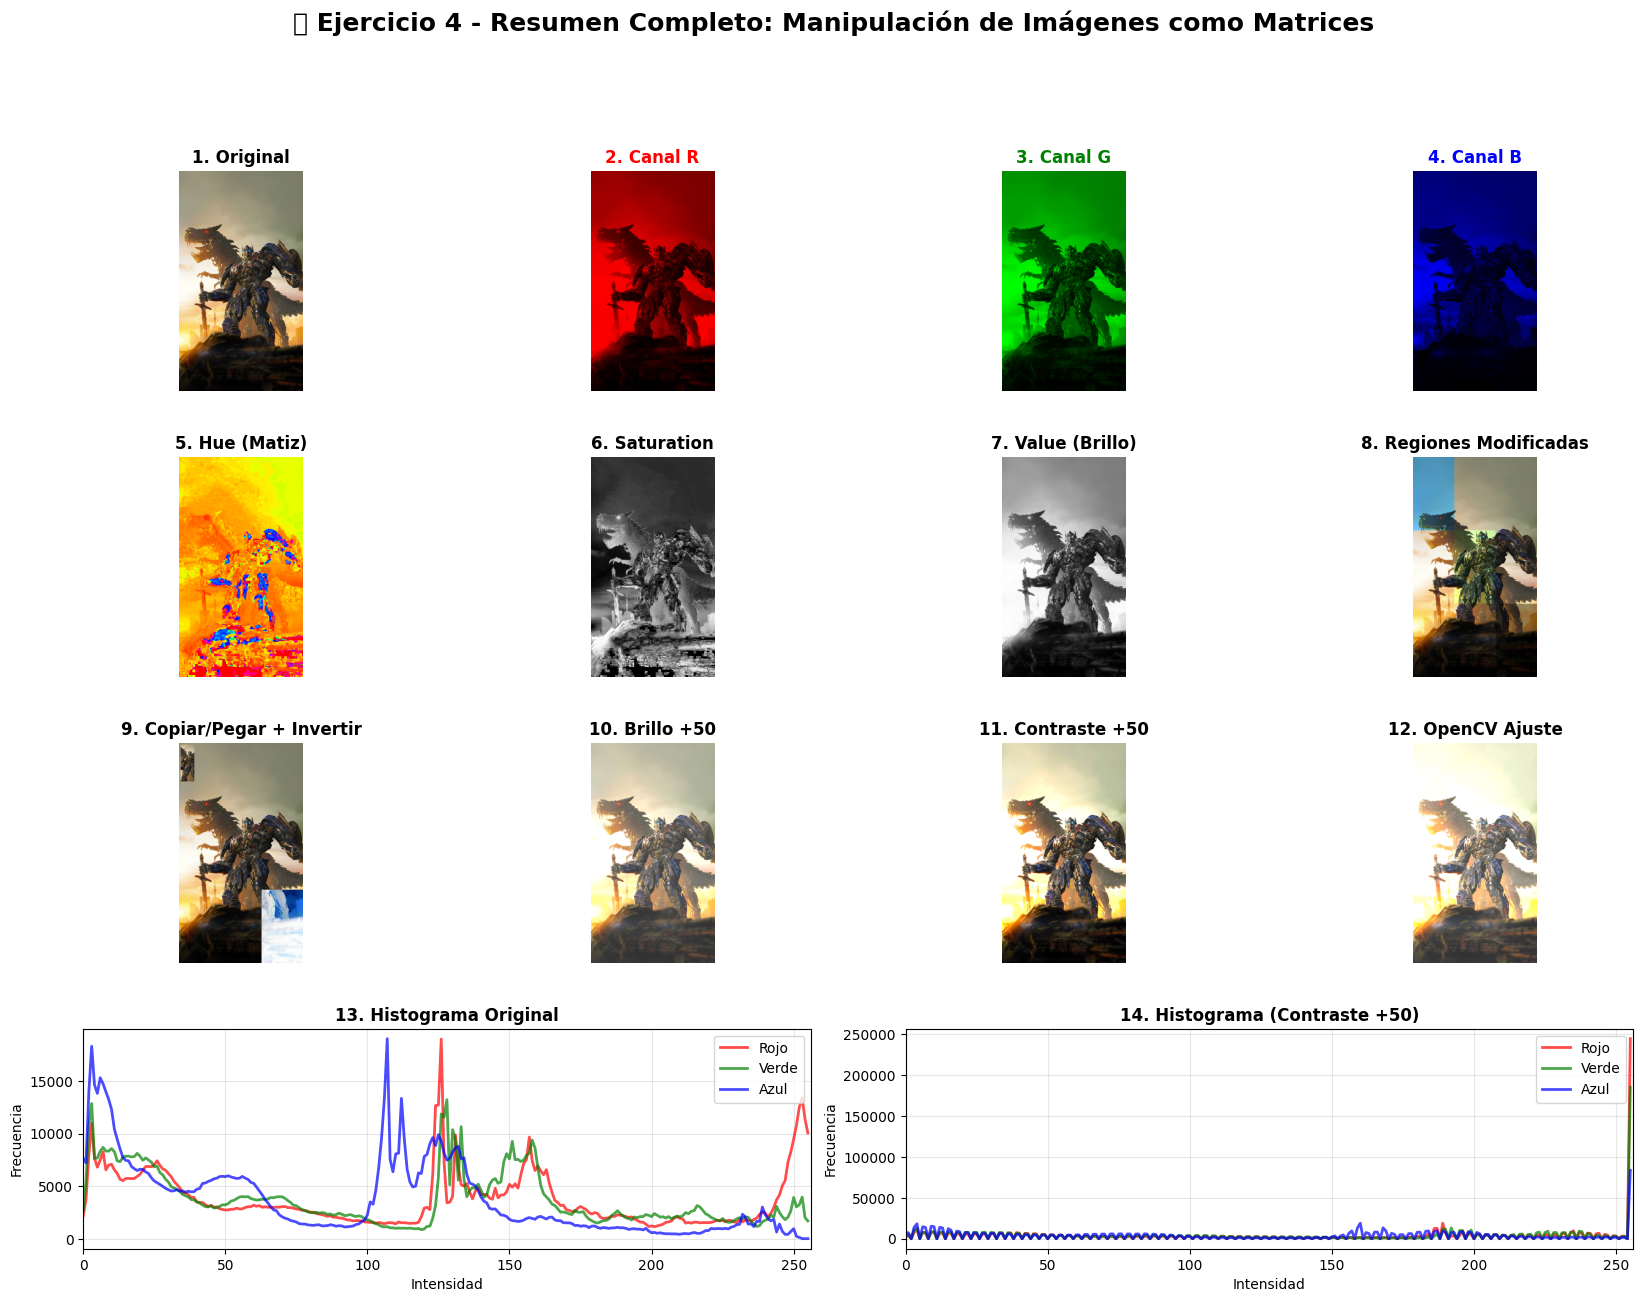

In [12]:
# Crear un resumen visual completo
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)

# Fila 1: Separación RGB
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(img_rgb)
ax1.set_title('1. Original', fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(img_r)
ax2.set_title('2. Canal R', fontweight='bold', color='red')
ax2.axis('off')

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(img_g)
ax3.set_title('3. Canal G', fontweight='bold', color='green')
ax3.axis('off')

ax4 = fig.add_subplot(gs[0, 3])
ax4.imshow(img_b)
ax4.set_title('4. Canal B', fontweight='bold', color='blue')
ax4.axis('off')

# Fila 2: Separación HSV
ax5 = fig.add_subplot(gs[1, 0])
ax5.imshow(H, cmap='hsv')
ax5.set_title('5. Hue (Matiz)', fontweight='bold')
ax5.axis('off')

ax6 = fig.add_subplot(gs[1, 1])
ax6.imshow(S, cmap='gray')
ax6.set_title('6. Saturation', fontweight='bold')
ax6.axis('off')

ax7 = fig.add_subplot(gs[1, 2])
ax7.imshow(V, cmap='gray')
ax7.set_title('7. Value (Brillo)', fontweight='bold')
ax7.axis('off')

ax8 = fig.add_subplot(gs[1, 3])
ax8.imshow(img_modified)
ax8.set_title('8. Regiones Modificadas', fontweight='bold')
ax8.axis('off')

# Fila 3: Operaciones de edición
ax9 = fig.add_subplot(gs[2, 0])
ax9.imshow(img_copy_paste)
ax9.set_title('9. Copiar/Pegar + Invertir', fontweight='bold')
ax9.axis('off')

ax10 = fig.add_subplot(gs[2, 1])
ax10.imshow(img_bright_up)
ax10.set_title('10. Brillo +50', fontweight='bold')
ax10.axis('off')

ax11 = fig.add_subplot(gs[2, 2])
ax11.imshow(img_contrast_up)
ax11.set_title('11. Contraste +50', fontweight='bold')
ax11.axis('off')

ax12 = fig.add_subplot(gs[2, 3])
ax12.imshow(img_opencv_both)
ax12.set_title('12. OpenCV Ajuste', fontweight='bold')
ax12.axis('off')

# Fila 4: Histogramas
ax13 = fig.add_subplot(gs[3, :2])
ax13.plot(hist_r, color='red', alpha=0.7, linewidth=2, label='Rojo')
ax13.plot(hist_g, color='green', alpha=0.7, linewidth=2, label='Verde')
ax13.plot(hist_b, color='blue', alpha=0.7, linewidth=2, label='Azul')
ax13.set_title('13. Histograma Original', fontweight='bold')
ax13.set_xlabel('Intensidad')
ax13.set_ylabel('Frecuencia')
ax13.legend()
ax13.grid(True, alpha=0.3)
ax13.set_xlim([0, 256])

ax14 = fig.add_subplot(gs[3, 2:])
ax14.plot(hist_r_contrast, color='red', alpha=0.7, linewidth=2, label='Rojo')
ax14.plot(hist_g_contrast, color='green', alpha=0.7, linewidth=2, label='Verde')
ax14.plot(hist_b_contrast, color='blue', alpha=0.7, linewidth=2, label='Azul')
ax14.set_title('14. Histograma (Contraste +50)', fontweight='bold')
ax14.set_xlabel('Intensidad')
ax14.set_ylabel('Frecuencia')
ax14.legend()
ax14.grid(True, alpha=0.3)
ax14.set_xlim([0, 256])

plt.suptitle('📊 Ejercicio 4 - Resumen Completo: Manipulación de Imágenes como Matrices', 
             fontsize=18, fontweight='bold', y=0.995)
plt.show()

